In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("synthetic_fraud_dataset.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (50000, 21)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [3]:
cols_drop = ["Transaction_ID", "User_ID", "Timestamp", "Fraud_Label"]
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

In [4]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()

if len(numeric_cols) == 0:
    raise ValueError("No se encontraron variables numéricas para usar como y.")

y_col = numeric_cols[0]
print("Variable objetivo seleccionada automáticamente:", y_col)

Variable objetivo seleccionada automáticamente: Transaction_Amount


In [5]:
X = df.drop(columns=[y_col])
y = df[y_col]

In [6]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Cantidad de variables numéricas:", len(num_cols))
print("Cantidad de variables categóricas:", len(cat_cols))

Cantidad de variables numéricas: 10
Cantidad de variables categóricas: 6


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

try:
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
except TypeError:
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [9]:
lasso = Lasso(max_iter=5000)

params = {
    "model__alpha": np.logspace(-4, 2, 20)
}

pipe = Pipeline([
    ("prep", preprocess),
    ("model", lasso)
])

grid = GridSearchCV(
    pipe,
    param_grid=params,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Account_Balance',
                                                                          'IP_Address_Flag',
                                                                          'Previous_Fraudulent_Activity',
                                                                          'Daily_Transaction_Count',
                                                                          'Avg_Transaction_Amount_7d',
                                                                          'Failed_Transaction_Count_7d',
                                                                          'Card_Age',
                                                                          'Tran...
             param_grid={'model__alpha': array([1.00000000e-04, 2.06913808e-04, 4.28133240e-04, 8.85866790e-04,
       1.83298071e-03, 3.79269019e-03, 7.84759970e-03, 1.62377674e-02,
       3.35981829e-02, 6.95192796e-02, 1.43844989e-01, 2.97635144e-01,
       6.15848211e-01, 1.27427499e+00, 2.63665090e+00, 5.45559478e+00,
       1.12883789e+01, 2.33572147e+01, 4.83293024e+01, 1.00000000e+02])},
             scoring='neg_mean_squared_error')

In [10]:
print("Mejor alpha encontrado:", grid.best_params_["model__alpha"])

y_pred = grid.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Mejor alpha encontrado: 2.6366508987303554

MAE: 72.90110429108572
RMSE: 99.23447800554844
R²: -5.31112992154803e-05


In [11]:
metrics_table = pd.DataFrame({
    "MAE": [mae],
    "RMSE": [rmse],
    "R²": [r2]
})

metrics_table

,MAE,RMSE,R²
0,72.901104,99.234478,-0.000053


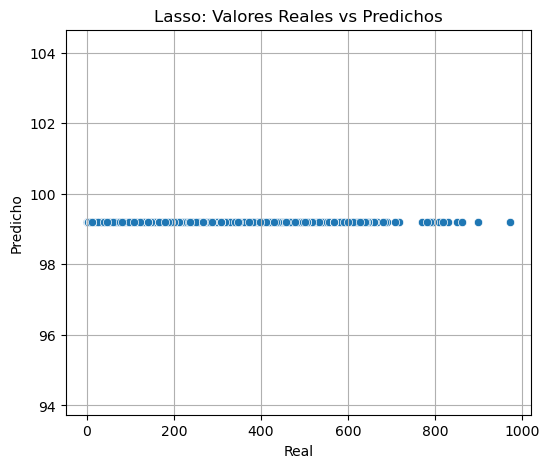

In [12]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Lasso: Valores Reales vs Predichos")
plt.grid(True)
plt.show()